Original shape: (330, 329, 4)
Fixed shape: (330, 329, 3)


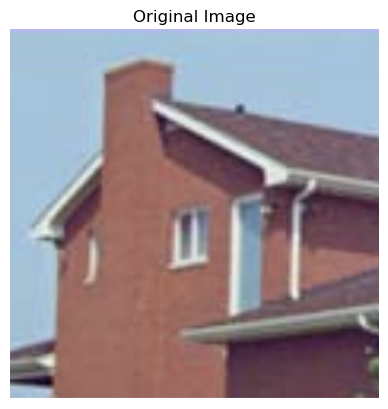

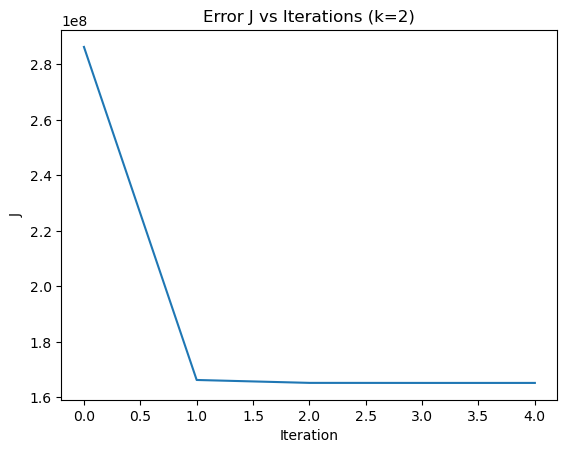

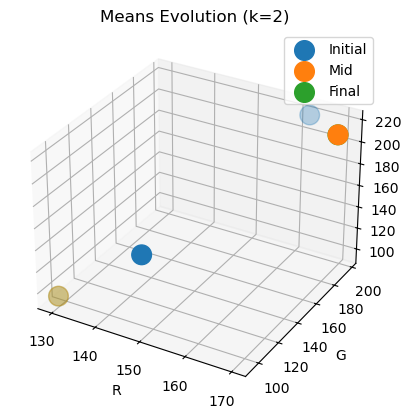

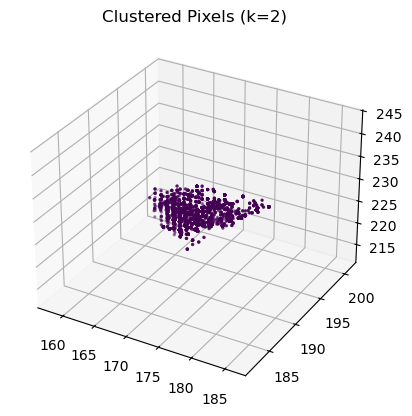

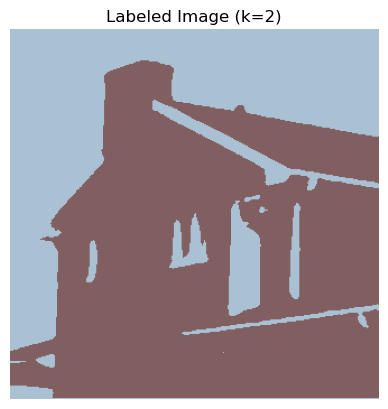

Initial Means Run 1:
 [[142. 123. 125.]
 [163. 197. 219.]
 [164. 193. 220.]
 [123.  97. 107.]
 [168. 195. 218.]]
Initial Means Run 2:
 [[161. 112. 101.]
 [155. 139. 143.]
 [103.  70.  78.]
 [166. 195. 220.]
 [166. 195. 216.]]


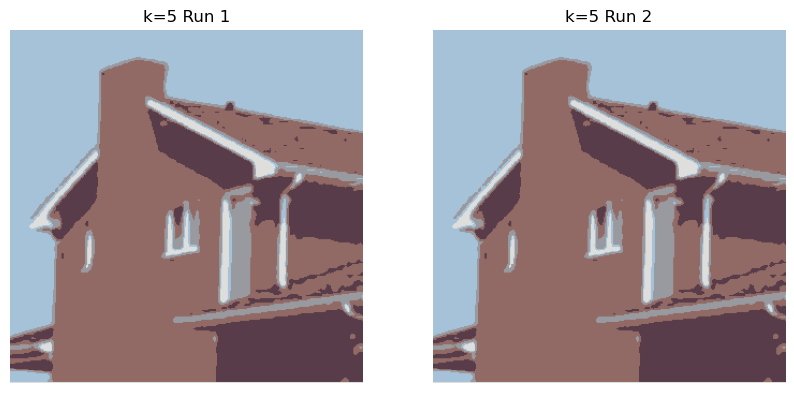

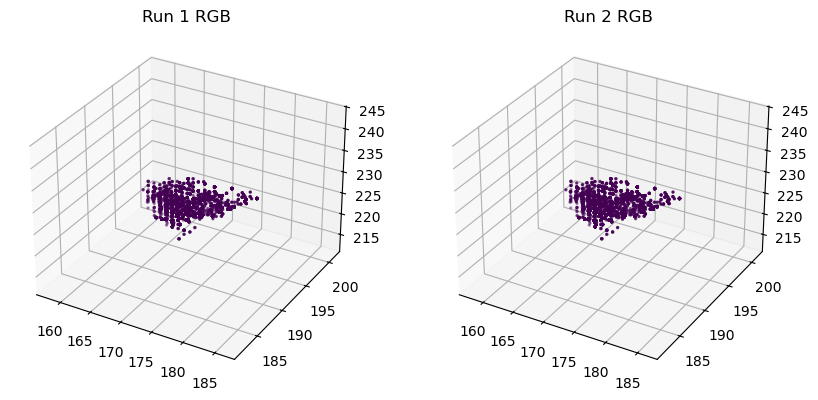

XB Run 1: 0.10606008045123978
XB Run 2: 0.10605945101785595
Run 2 is better clustering (lower XB).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from mpl_toolkits.mplot3d import Axes3D

# ==============================
# LOAD + FIX IMAGE
# ==============================
I = imageio.imread('house.tiff')

print("Original shape:", I.shape)

# Ensure RGB
if len(I.shape) == 2:
    I = np.stack((I,)*3, axis=-1)
elif I.shape[2] == 4:
    I = I[:, :, :3]

print("Fixed shape:", I.shape)

plt.imshow(I)
plt.title("Original Image")
plt.axis('off')
plt.show()

# Reshape
M, N, _ = I.shape
X = I.reshape(M * N, 3).astype(np.float64)

# ==============================
# K-MEANS FUNCTION (WITH HISTORY)
# ==============================
def kmeans(X, k, max_iters=50, seed=42):
    np.random.seed(seed)

    indices = np.random.choice(len(X), k, replace=False)
    means = X[indices]

    initial_means = means.copy()
    means_history = [means.copy()]
    J_history = []

    for iteration in range(max_iters):
        distances = np.linalg.norm(X[:, np.newaxis] - means, axis=2)
        labels = np.argmin(distances, axis=1)

        # Compute J
        J = 0
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                J += np.sum((cluster_points - means[i])**2)
        J_history.append(J)

        # Update means
        new_means = []
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                new_means.append(np.mean(cluster_points, axis=0))
            else:
                new_means.append(means[i])
        new_means = np.array(new_means)

        means_history.append(new_means.copy())

        if np.allclose(means, new_means):
            break

        means = new_means

    return means, labels, J_history, initial_means, means_history

# ==============================
# PART 1 — k = 2
# ==============================
k = 2
means, labels, J_history, initial_means, means_history = kmeans(X, k)

# (a) Plot J
plt.plot(J_history)
plt.title("Error J vs Iterations (k=2)")
plt.xlabel("Iteration")
plt.ylabel("J")
plt.show()

# (b) Plot initial, mid, final means
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

mid_means = means_history[len(means_history)//2]

ax.scatter(initial_means[:,0], initial_means[:,1], initial_means[:,2], s=200, label="Initial")
ax.scatter(mid_means[:,0], mid_means[:,1], mid_means[:,2], s=200, label="Mid")
ax.scatter(means[:,0], means[:,1], means[:,2], s=200, label="Final")

ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')
plt.legend()
plt.title("Means Evolution (k=2)")
plt.show()

# (c) RGB scatter
sample = X[:5000]
sample_labels = labels[:5000]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(sample[:,0], sample[:,1], sample[:,2], c=sample_labels, s=2)
plt.title("Clustered Pixels (k=2)")
plt.show()

# (d) Labeled image
X_labeled = means[labels]
I_labeled = X_labeled.reshape(M, N, 3).astype(np.uint8)

plt.imshow(I_labeled)
plt.title("Labeled Image (k=2)")
plt.axis('off')
plt.show()

# ==============================
# PART 2 — k = 5 (TWO RUNS)
# ==============================

# Run 1
means1, labels1, _, init1, _ = kmeans(X, 5, seed=42)

# Run 2
means2, labels2, _, init2, _ = kmeans(X, 5, seed=7)

print("Initial Means Run 1:\n", init1)
print("Initial Means Run 2:\n", init2)

# Show images
I1 = means1[labels1].reshape(M, N, 3).astype(np.uint8)
I2 = means2[labels2].reshape(M, N, 3).astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(I1)
plt.title("k=5 Run 1")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(I2)
plt.title("k=5 Run 2")
plt.axis('off')

plt.show()

# RGB scatter for both
sample = X[:5000]

fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(sample[:,0], sample[:,1], sample[:,2], c=labels1[:5000], s=2)
ax1.set_title("Run 1 RGB")

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(sample[:,0], sample[:,1], sample[:,2], c=labels2[:5000], s=2)
ax2.set_title("Run 2 RGB")

plt.show()

# ==============================
# PART 3 — XB INDEX
# ==============================
def xb_index(X, means, labels):
    N = len(X)
    k = len(means)

    num = 0
    for i in range(k):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            num += np.sum((cluster_points - means[i])**2)

    min_dist = np.inf
    for i in range(k):
        for j in range(i+1, k):
            dist = np.linalg.norm(means[i] - means[j])**2
            if dist < min_dist:
                min_dist = dist

    return num / (N * min_dist)

xb1 = xb_index(X, means1, labels1)
xb2 = xb_index(X, means2, labels2)

print("XB Run 1:", xb1)
print("XB Run 2:", xb2)

# ==============================
# FINAL COMPARISON PRINT
# ==============================
if xb1 < xb2:
    print("Run 1 is better clustering (lower XB).")
else:
    print("Run 2 is better clustering (lower XB).")